# Cargar documentos

In [72]:
import sys
print(sys.executable)

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/bin/python


In [73]:
import os
import pandas as pd 
import numpy as np

In [74]:
active_subjects = pd.read_csv(os.path.join("..", "..","data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("..", "..","data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("..", "..","data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("..", "..","data", 'passive_subjects.csv'))

In [75]:
df_grande = pd.merge(
    active_subjects,
    audiences,
    on='audiencia_id',
    how='inner'  # solo registros que existen en ambos
)

In [76]:
df = df_grande.copy()
df = df[['sujeto_pasivo_id_x','Nombre completo','materias_tratadas','especificacion']]
df = df.rename(columns={
    'sujeto_pasivo_id_x': 'pasivo_id',
    'Nombre completo': 'activo_id',
    'materias_tratadas': 'temas',
    'especificacion': 'detalle'
})

In [77]:
ruta_parquet = 'lobby_data_para_gpu.parquet'
df_parquet = pd.read_parquet(ruta_parquet)

# 2. Reemplazas la columna (usando .values para asignar por posición estricta)
# Esto asume que df tiene la misma cantidad de filas y el mismo orden que el parquet
df['detalle'] = df_parquet['detalle'].values

In [24]:
df['detalle'][1]

'Socios de JJVV de Caquena solicitan audiencia presencial con Delegado debido a traslado de alumnos de colegio desde Caquena a Chujlluta por falta de profesores. Vecinos buscan solución y acuden al Deelgado para realizar nexo con Seremi de Educación'

In [25]:
df

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...
...,...,...,...,...
1153805,391700,JAIME OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153806,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153807,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153808,712954,Margarita Corrotea,"Diseño, implementación y evaluación de polític...","encomendada compañía ESVAL, entregar informaci..."


# Modelo recomendador

In [ ]:
import umap
import hdbscan
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import numpy as np

print("=== BLOQUE 2: RE-CLUSTERING (MAPA NUEVO) ===")

# 1. PCA (768 -> 50)
print("1. Ejecutando PCA...")
# Normalizamos antes de PCA para que la distancia coseno funcione óptimamente
emb_norm = normalize(emb_detalle) 
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(emb_norm)

# 2. UMAP Híbrido (Para cuidar la RAM)
print("2. Ejecutando UMAP...")
# Entrenamos el mapa solo con una muestra de 200k (suficiente para aprender la topología)
mapper = umap.UMAP(
    n_neighbors=5, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42, 
    low_memory=True,
    verbose=True
).fit(emb_pca[:200000]) 

# Proyectamos todo el dataset por partes para no saturar memoria
print("   Proyectando el resto de los datos...")
umap_embeddings_list = []
batch_size = 50000

for i in range(0, len(emb_pca), batch_size):
    batch = emb_pca[i : i + batch_size]
    batch_emb = mapper.transform(batch)
    umap_embeddings_list.append(batch_emb)

umap_embeddings = np.vstack(umap_embeddings_list)
print(f"   Mapa UMAP listo: {umap_embeddings.shape}")

# 3. HDBSCAN (Etiquetado)
print("3. Ejecutando HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(umap_embeddings)

# Actualizamos el DataFrame
df['cluster_final'] = labels

# Reporte
n_clusters = len(np.unique(labels)) - 1
ruido = (len(labels[labels == -1]) / len(labels)) * 100
print(f"✅ ¡Nuevos Clusters Listos!")
print(f"   Total Clusters: {n_clusters}")
print(f"   Ruido: {ruido:.2f}%")

=== BLOQUE 2A: REDUCCIÓN DE DIMENSIONALIDAD (PCA + UMAP) ===
1. Ejecutando PCA...
2. Ejecutando UMAP...
   Entrenando mapa con 600000 documentos...
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, random_state=42, verbose=True)
Fri Nov 28 23:14:32 2025 Construct fuzzy simplicial set
Fri Nov 28 23:14:32 2025 Finding Nearest Neighbors
Fri Nov 28 23:14:32 2025 Building RP forest with 44 trees


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Nov 28 23:14:44 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	 6  /  19
	Stopping threshold met -- exiting after 6 iterations
Fri Nov 28 23:15:14 2025 Finished Nearest Neighbor Search
Fri Nov 28 23:15:15 2025 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  50  /  100 epochs
	completed  60  /  100 epochs


Epochs completed:  83%| ████████▎  83/100 [00:01]

	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:01]

✅ Mapa UMAP listo: (1153810, 5)


In [ ]:
import hdbscan
import numpy as np
import pandas as pd # Aseguramos que pandas esté importado

print("=== RE-TUNING HDBSCAN (MENOS RUIDO) ===")

# AJUSTES NUEVOS
# min_cluster_size: Bajamos de 150 a 100 para aceptar temas medianos
# min_samples: Bajamos de 30 a 10 (ESTO ES LO QUE BAJA EL RUIDO DRASTICAMENTE)
new_min_cluster_size = 100
new_min_samples = 10

print(f"Ejecutando con Size={new_min_cluster_size}, Samples={new_min_samples}...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=new_min_cluster_size,
    min_samples=new_min_samples,
    metric='euclidean',
    cluster_selection_method='eom', 
    prediction_data=True
)

labels = clusterer.fit_predict(umap_embeddings)

# Actualizamos DF
df['cluster_final'] = labels

# Métricas
n_clusters = len(np.unique(labels)) - 1
ruido_pct = (len(labels[labels == -1]) / len(labels)) * 100

print(f"\n📊 RESULTADOS MEJORADOS:")
print(f"   Total Clusters: {n_clusters}")
print(f"   Ruido: {ruido_pct:.2f}%")

if ruido_pct < 40:
    print("   ✅ ¡Excelente! Ruido bajo control.")
else:
    print("   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.")

=== RE-TUNING HDBSCAN (MENOS RUIDO) ===
Ejecutando con Size=100, Samples=10...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
Python(62292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(62293


📊 RESULTADOS MEJORADOS:
   Total Clusters: 1279
   Ruido: 54.42%
   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.


In [ ]:
df.head()

,pasivo_id,activo_id,temas,detalle,cluster_final
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,1213
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,1147
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,-1
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,-1
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,1272


In [ ]:
import joblib
import os

print("=== GUARDANDO SISTEMA COMPLETO ===")

# Crear carpeta
os.makedirs("sistema_lobby_final", exist_ok=True)

# 1. Guardar Modelos de Reducción y Clustering
print("Guardando modelos (PCA, UMAP, HDBSCAN)...")
joblib.dump(pca, "sistema_lobby_final/pca_model.joblib")
joblib.dump(mapper, "sistema_lobby_final/umap_model.joblib")
joblib.dump(clusterer, "sistema_lobby_final/hdbscan_model.joblib")

# 2. Guardar DataFrame Enriquecido (Con clusters y limpio)
print("Guardando Base de Datos Maestra...")
df.to_parquet("sistema_lobby_final/df_lobby_clustered.parquet")

# 3. Guardar Embeddings Alineados
print("Guardando Vectores...")
np.save("sistema_lobby_final/embeddings_bert.npy", emb_detalle)

print("✅ ¡TODO GUARDADO! Tu sistema es persistente.")
print("La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.")

=== GUARDANDO SISTEMA COMPLETO ===
Guardando modelos (PCA, UMAP, HDBSCAN)...
Guardando Base de Datos Maestra...
Guardando Vectores...
✅ ¡TODO GUARDADO! Tu sistema es persistente.
La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.


# Metricas en el modelo

Cargamos los datos medidos anteriormemente

In [17]:
# Librerias
import joblib
import os
import torch
import numpy as np
import pandas as pd
import hdbscan
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
import sys
from contextlib import contextmanager
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [15]:

class LobbyRecommender:
    def __init__(self, df_data, embeddings_bert, pca, mapper, clusterer):
        """
        Inicializa el sistema y silencia los modelos internos.
        """
        self.df = df_data.reset_index(drop=True)
        self.embs = embeddings_bert
        self.pca = pca
        
        # --- SILENCIADOR AUTOMÁTICO ---
        # Forzamos a UMAP a guardar silencio, sin importar cómo se entrenó
        self.mapper = mapper
        self.mapper.verbose = False 
        
        self.clusterer = clusterer
        
        # 1. Configuración BERT
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🔄 Iniciando Recommender en: {self.device}")
        
        model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        
        # 2. Entrenar GPS (KNN)
        print("🧠 Entrenando sistema de navegación (KNN)...")
        embs_norm = normalize(self.embs)
        X_pca_train = self.pca.transform(embs_norm)
        y_labels = self.df['cluster_final'].values 
        
        self.router_knn = KNeighborsClassifier(n_neighbors=15)
        self.router_knn.fit(X_pca_train, y_labels)
        
        print(f"✅ Sistema listo. Total temas disponibles: {len(np.unique(y_labels))}")

    def get_single_embedding(self, text):
        """Genera embedding usando Mean Pooling corregido (sin padding)."""
        inputs = self.tokenizer([str(text)], padding=True, truncation=True,
                                return_tensors='pt', max_length=128).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs['attention_mask']
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            emb = sum_embeddings / sum_mask
            
        return emb.cpu().numpy()

    def recomendar(self, nuevo_texto, top_k=5):
        # 1. Vectorizar
        vec_raw = self.get_single_embedding(nuevo_texto)
        vec_norm = normalize(vec_raw)
        
        # 2. Ubicar (UMAP ahora será silencioso)
        vec_pca = self.pca.transform(vec_norm)
        vec_umap = self.mapper.transform(vec_pca)
        
        # 3. Asignar Cluster
        try:
            cluster_id, _ = hdbscan.approximate_predict(self.clusterer, vec_umap)
            cluster_asignado = cluster_id[0]
        except:
            cluster_asignado = -1
            
        metodo = "HDBSCAN"
        if cluster_asignado == -1:
            cluster_asignado = self.router_knn.predict(vec_pca)[0]
            metodo = "KNN (Rescate)"
            
        # 4. Buscar
        candidatos_idx = self.df.index[self.df['cluster_final'] == cluster_asignado].tolist()
        if not candidatos_idx: 
            candidatos_idx = self.df.index.tolist()
            
        embs_candidatos = self.embs[candidatos_idx]
        similitudes = cosine_similarity(vec_raw, embs_candidatos)[0]
        
        top_indices = similitudes.argsort()[::-1][:top_k]
        
        resultados = []
        for loc_idx in top_indices:
            real_idx = candidatos_idx[loc_idx]
            row = self.df.iloc[real_idx]
            resultados.append({
                'pasivo_id': row['pasivo_id'],
                'similitud': float(similitudes[loc_idx]),
                'detalle': str(row['detalle'])[:200] + "...",
                'cluster': int(cluster_asignado),
                'metodo': metodo
            })
            
        return pd.DataFrame(resultados)

In [33]:
# Ruta donde guardaste los archivos
CARPETA_MODELOS = "sistema_lobby_final"

print("=== CARGANDO SISTEMA ===")

if not os.path.exists(CARPETA_MODELOS):
    print(f"❌ ERROR: No encuentro la carpeta '{CARPETA_MODELOS}'.")
    print("   Asegúrate de estar en el directorio correcto o ajusta la ruta.")
else:
    try:
        # 1. Cargar Modelos
        print("📂 Cargando modelos (PCA, UMAP, HDBSCAN)...")
        pca_loaded = joblib.load(f"{CARPETA_MODELOS}/pca_model.joblib")
        mapper_loaded = joblib.load(f"{CARPETA_MODELOS}/umap_model.joblib")
        clusterer_loaded = joblib.load(f"{CARPETA_MODELOS}/hdbscan_model.joblib")

        # 2. Cargar Datos
        print("📂 Cargando Base de Datos (Parquet)...")
        df_loaded = pd.read_parquet(f"{CARPETA_MODELOS}/df_lobby_clustered.parquet")

        # 3. Cargar Vectores
        print("📂 Cargando Embeddings (NPY)...")
        embs_loaded = np.load(f"{CARPETA_MODELOS}/embeddings_bert.npy")

        print("✅ ¡Archivos cargados correctamente!")
        
        # 4. Inicializar Recomendador
        print("\n🚀 Levantando LobbyRecommender...")
        recsys = LobbyRecommender(
            df_data=df_loaded,
            embeddings_bert=embs_loaded,
            pca=pca_loaded,
            mapper=mapper_loaded,
            clusterer=clusterer_loaded
        )
        
        print("\n✨ ¡SISTEMA LISTO PARA USAR!")

    except Exception as e:
        print(f"❌ Ocurrió un error al cargar: {e}")

=== CARGANDO SISTEMA ===
📂 Cargando modelos (PCA, UMAP, HDBSCAN)...
Sat Nov 29 14:14:24 2025 Building and compiling search function
📂 Cargando Base de Datos (Parquet)...
📂 Cargando Embeddings (NPY)...
✅ ¡Archivos cargados correctamente!

🚀 Levantando LobbyRecommender...
🔄 Iniciando Recommender en: cpu
🧠 Entrenando sistema de navegación (KNN)...
✅ Sistema listo. Total temas disponibles: 1779

✨ ¡SISTEMA LISTO PARA USAR!


In [34]:
# 1. Calcular cuántas veces aparece cada pasivo_id en la base de datos
print("Calculando carga de trabajo histórica (Ocupación)...")

# value_counts() nos da la frecuencia (número de reuniones)
mapa_ocupacion = df['pasivo_id'].value_counts().to_dict()

# Ejemplo de verificacion
top_1 = list(mapa_ocupacion.keys())[0]
print(f"✅ Cálculo listo. El sujeto más ocupado (ID {top_1}) tiene {mapa_ocupacion[top_1]} reuniones.")

def get_ocupacion(p_id):
    return mapa_ocupacion.get(p_id, 0)

Calculando carga de trabajo histórica (Ocupación)...
✅ Cálculo listo. El sujeto más ocupado (ID 10832) tiene 12458 reuniones.


In [ ]:

def visualizar_perfil_profesional(df_resultados, df_original, mapa_ocupacion, recsys, texto_query, verbose=True):
    """
    Versión 4.0:
    - Retorna una lista con los 'pasivo_id' recomendados.
    - verbose=False: Silencia los prints (ideal para loops de evaluación).
    - verbose=True: Muestra el reporte completo (sin Temática, solo Cluster ID).
    - Optimización: No calcula antecedentes si verbose=False (ahorra tiempo).
    """
    
    predicted_ids = []
    
    # Solo calculamos el vector de la query si vamos a imprimir detalles visuales
    if verbose:
        vec_query = recsys.get_single_embedding(texto_query).reshape(1, -1)
        print(f"\nINFORME DE RECOMENDACIÓN DE SUJETOS PASIVOS")
        print("=" * 80)
        print(f"CONSULTA: '{texto_query}'")
        print("=" * 80)
    
    # Iteramos sobre los candidatos
    for i, row in df_resultados.iterrows():
        p_id = row['pasivo_id']
        
        # 1. GUARDAR ID (Para evaluación)
        predicted_ids.append(p_id)
        
        # Si NO queremos ver detalles, saltamos al siguiente
        if not verbose:
            continue

        # --- A PARTIR DE AQUÍ SOLO SE EJECUTA SI VERBOSE=TRUE ---
        similitud_global = row['similitud']
        cluster_id = row['cluster']
        total_reuniones = mapa_ocupacion.get(p_id, 0)
        
        try:
            nombre_sujeto = df_original[df_original['pasivo_id'] == p_id].iloc[0]['activo_id']
        except:
            nombre_sujeto = "NOMBRE NO REGISTRADO"

        # --- B. BUSCAR ANTECEDENTES (Solo para visualización) ---
        indices_sujeto = df_original.index[df_original['pasivo_id'] == p_id].tolist()
        vectores_sujeto = recsys.embs[indices_sujeto]
        sims_local = cosine_similarity(vec_query, vectores_sujeto)[0]
        sorted_indices = sims_local.argsort()[::-1]
        
        top_cases_unicos = []
        textos_vistos = set()
        
        for idx_local in sorted_indices:
            idx_real = indices_sujeto[idx_local]
            txt_caso = str(df_original.iloc[idx_real]['detalle']).strip()
            score_caso = sims_local[idx_local]
            
            if txt_caso in textos_vistos: continue
            textos_vistos.add(txt_caso)
            top_cases_unicos.append((txt_caso, score_caso))
            if len(top_cases_unicos) >= 3: break
        
        # --- C. IMPRESIÓN (Sin Temática) ---
        print(f"\nCANDIDATO #{i+1}")
        print("-" * 80)
        print(f"NOMBRE      : {nombre_sujeto}")
        print(f"ID INTERNO  : {p_id}")
        print(f"AFINIDAD    : {similitud_global:.4f}")
        print(f"HISTORIAL   : {total_reuniones} reuniones")
        print(f"CLUSTER ID  : {cluster_id}") # Solo el número
        print("-" * 80)
        print("TOP 3 ANTECEDENTES ÚNICOS:")
        
        for k, (txt, score) in enumerate(top_cases_unicos):
            txt_limpio = txt[:250] + "..." if len(txt) > 250 else txt
            print(f"  {k+1}. [Similitud: {score:.4f}]")
            print(f"     \"{txt_limpio}\"")
            print()
            
        print("\n")
        
    # Retornamos la lista de IDs para que puedas calcular métricas
    return predicted_ids

In [36]:
texto = "reparacion vivienda."
df_rec = recsys.recomendar(texto, top_k=5)

# verbose=True por defecto
ids_recomendados = visualizar_perfil_profesional(df_rec, df, mapa_ocupacion, recsys, texto, verbose=True)

Python(91991) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Epochs completed: 100%| ██████████ 100/100 [00:00]
Python(91992) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



INFORME DE RECOMENDACIÓN DE SUJETOS PASIVOS
CONSULTA: 'reparacion vivienda.'

CANDIDATO #1
--------------------------------------------------------------------------------
NOMBRE      : Nadia Silva
ID INTERNO  : 312933
AFINIDAD    : 0.8651
HISTORIAL   : 32 reuniones
CLUSTER ID  : 2507
--------------------------------------------------------------------------------
TOP 3 ANTECEDENTES ÚNICOS:
  1. [Similitud: 0.8651]
     "reconstrucción de vivienda"

  2. [Similitud: 0.3024]
     "Solicitud a vecina de la representada para regularizar la forma en la cual está construyendo el segundo piso de su vivienda, ya que con ello causó daños estructurales y se niega a repararlos y conceder permiso para hacerlo por cuenta de la representa..."

  3. [Similitud: 0.2677]
     "Para revisar y consultar sobre el estado de revisión de las solicitudes de modificación de deslindes y modificación de permiso de edificación ingresos Nº2023/00163 del 13.06.2023 y Nº2023/00162 del 13.06.2023 respectivamente. A

In [37]:
# Ejemplo de evaluación manual rápida
texto_prueba = "Solicitud de reunión para presentar proyecto habitacional de viviendas sociales."
target_id_real = 87290 # Supongamos que este es el ID correcto que esperas

# Obtenemos recomendaciones
df_rec = recsys.recomendar(texto_prueba, top_k=10)

# Obtenemos SOLO los IDs (sin imprimir nada en pantalla)
lista_ids_predichos = visualizar_perfil_profesional(df_rec, df, mapa_ocupacion, recsys, texto_prueba, verbose=False)

print(f"IDs Predichos: {lista_ids_predichos}")

# Evaluamos
if target_id_real in lista_ids_predichos:
    print("✅ ¡ÉXITO! El ID correcto fue encontrado.")
else:
    print("❌ Fallo. El ID correcto no está en la lista.")

Epochs completed: 100%| ██████████ 100/100 [00:00]

IDs Predichos: [80325, 80325, 80325, 80325, 80325, 4257, 4257, 4257, 4257, 4257]
❌ Fallo. El ID correcto no está en la lista.


In [40]:

# 1. Definir el Silenciador TOTAL (Stdout + Stderr)
@contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# 2. Función de Evaluación Actualizada
def evaluar_hit_rates(recsys, n_muestras=100):
    print(f"=== EVALUACIÓN DE HIT RATE (Muestra: {n_muestras}) ===")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    hits_5 = 0
    hits_10 = 0
    hits_20 = 0
    
    # Barra de progreso limpia
    # (Esta SÍ se verá porque está fuera del silenciador)
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Evaluando"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        try:
            # --- ZONA DE SILENCIO ---
            # Aquí adentro nada puede imprimir, ni UMAP ni nadie.
            with suppress_all_output():
                df_res = recsys.recomendar(texto_query, top_k=20)
            # ------------------------
            
            ids_recomendados = df_res['pasivo_id'].tolist()
            
            if target_id in ids_recomendados[:5]: hits_5 += 1
            if target_id in ids_recomendados[:10]: hits_10 += 1
            if target_id in ids_recomendados[:20]: hits_20 += 1
                
        except Exception as e:
            # Si falla, imprimimos fuera del bloque silencioso
            print(f"Error: {e}")
            continue

    hr_5 = (hits_5 / n_muestras) * 100
    hr_10 = (hits_10 / n_muestras) * 100
    hr_20 = (hits_20 / n_muestras) * 100
    
    print("\n📊 RESULTADOS DE RENDIMIENTO:")
    print(f"   🎯 Hit Rate @ 5 : {hr_5:.2f}%")
    print(f"   🎯 Hit Rate @ 10: {hr_10:.2f}%")
    print(f"   🎯 Hit Rate @ 20: {hr_20:.2f}%")
    
    return {"HR@5": hr_5, "HR@10": hr_10, "HR@20": hr_20}

In [41]:

def evaluar_confusion_clusters(recsys, n_muestras=500, top_n_clusters=15):
    """
    Genera la matriz de confusión para los clusters.
    Filtra solo los 'top_n_clusters' más frecuentes para que el gráfico sea legible.
    """
    print(f"=== MATRIZ DE CONFUSIÓN DE CLUSTERS (Muestra: {n_muestras}) ===")
    
    # 1. Muestra aleatoria
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    
    y_true = []
    y_pred = []
    
    print("Prediciendo clusters...")
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras):
        texto = row['detalle']
        cluster_real = row['cluster_final']
        
        # Obtenemos la predicción del sistema
        # Pedimos 1 recomendación solo para ver qué cluster asigna el recomendador internamente
        try:
            # recsys.recomendar devuelve un DF, tomamos la columna 'cluster' de la primera fila
            # OJO: Esto asume que tu método recomendar retorna la columna 'cluster'
            res = recsys.recomendar(texto, top_k=1)
            cluster_predicho = res.iloc[0]['cluster']
            
            y_true.append(cluster_real)
            y_pred.append(cluster_predicho)
        except:
            continue
            
    # 2. Filtrar para el Gráfico (Top N Clusters más populares en la muestra)
    # Convertimos a Series para contar rápido
    s_true = pd.Series(y_true)
    top_clusters = s_true.value_counts().head(top_n_clusters).index.tolist()
    
    # Filtramos las listas para quedarnos solo con datos de esos clusters top
    # Esto es vital porque graficar 1200 clusters colapsaría tu pantalla
    indices_filtrados = [i for i, x in enumerate(y_true) if x in top_clusters and y_pred[i] in top_clusters]
    
    y_true_f = [y_true[i] for i in indices_filtrados]
    y_pred_f = [y_pred[i] for i in indices_filtrados]
    
    # 3. Precisión Global (De todos, no solo los filtrados)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Precisión Global de Asignación de Cluster: {acc:.2%}")
    print(f"   (Qué tan a menudo el sistema asigna el mismo cluster original)")

    # 4. Graficar Matriz
    if len(y_true_f) > 0:
        cm = confusion_matrix(y_true_f, y_pred_f, labels=top_clusters)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=top_clusters, yticklabels=top_clusters)
        plt.xlabel('Cluster Predicho')
        plt.ylabel('Cluster Real')
        plt.title(f'Matriz de Confusión (Top {top_n_clusters} Clusters más frecuentes)')
        plt.show()
    else:
        print("⚠️ No hay suficientes datos en los top clusters para graficar.")

In [42]:
# 1. APAGAR EL RUIDO DE UMAP (Crucial)
recsys.mapper.verbose = False

# 2. Ejecutar Evaluación
# (Asegúrate de tener la función evaluar_hit_rates definida)
metricas = evaluar_hit_rates(recsys, n_muestras=1000)

=== EVALUACIÓN DE HIT RATE (Muestra: 1000) ===


Evaluando: 100%|██████████| 1000/1000 [00:33<00:00, 29.42it/s]


📊 RESULTADOS DE RENDIMIENTO:
   🎯 Hit Rate @ 5 : 78.10%
   🎯 Hit Rate @ 10: 79.00%
   🎯 Hit Rate @ 20: 79.80%


In [143]:

def evaluar_mrr(recsys, n_muestras=100, top_k=20):
    print(f"=== EVALUACIÓN DE MRR (Muestra: {n_muestras}) ===")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    reciprocal_ranks = []
    
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Calculando MRR"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        try:
            # Silenciamos UMAP
            with suppress_all_output():
                df_res = recsys.recomendar(texto_query, top_k=top_k)
            
            ids_recomendados = df_res['pasivo_id'].tolist()
            
            if target_id in ids_recomendados:
                # Obtenemos el índice (0-based) y sumamos 1 para el ranking (1-based)
                rank = ids_recomendados.index(target_id) + 1
                reciprocal_ranks.append(1 / rank)
            else:
                # Si no está en el top K, el puntaje es 0
                reciprocal_ranks.append(0)
                
        except Exception as e:
            continue

    mrr_score = np.mean(reciprocal_ranks)
    
    print(f"\n📊 RESULTADO MRR@{top_k}:")
    print(f"   🏆 MRR: {mrr_score:.4f}")
    
    # Interpretación rápida
    pos_promedio = 1 / mrr_score if mrr_score > 0 else 0
    print(f"   (Equivale a encontrar la respuesta correcta, en promedio, en la posición: {pos_promedio:.1f})")
    
    return mrr_score

# --- EJECUTAR EVALUACIÓN ---
mrr = evaluar_mrr(recsys, n_muestras=1000, top_k=20)

=== EVALUACIÓN DE MRR (Muestra: 1000) ===


Calculando MRR: 100%|██████████| 1000/1000 [00:31<00:00, 31.59it/s]


📊 RESULTADO MRR@20:
   🏆 MRR: 0.7669
   (Equivale a encontrar la respuesta correcta, en promedio, en la posición: 1.3)


# Graficas

In [49]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_distances
import sys
import os
from contextlib import contextmanager

# Contexto para silenciar (Si no lo tienes definido de antes)
@contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

def evaluar_metricas_obligatorias(recsys, n_muestras=100, k=10):
    print(f"=== EVALUACIÓN DE MÉTRICAS OFICIALES (@{k}) ===")
    print(f"Muestra: {n_muestras} casos aleatorios.")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    
    # Listas para guardar puntajes por iteración
    recalls = []
    ndcgs = []
    maps = []
    diversities = []
    
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Calculando"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        try:
            # 1. Obtener Recomendaciones (Silencioso)
            with suppress_all_output():
                df_res = recsys.recomendar(texto_query, top_k=k)
            
            ids_rec = df_res['pasivo_id'].tolist()
            
            # --- A. CÁLCULO DE RECALL (Hit Rate) ---
            # 1 si está presente, 0 si no
            is_hit = 1 if target_id in ids_rec else 0
            recalls.append(is_hit)
            
            # --- B. CÁLCULO DE MAP & nDCG ---
            # En Leave-One-Out (1 solo relevante), MAP = MRR y nDCG se simplifica
            if is_hit:
                # Posición (0-based)
                rank_idx = ids_rec.index(target_id)
                rank_pos = rank_idx + 1 # 1-based
                
                # MAP (Precision at K para 1 item = 1/rank)
                maps.append(1 / rank_pos)
                
                # nDCG
                # DCG = rel_i / log2(i+2). rel_i es 1.
                dcg = 1 / np.log2(rank_pos + 1)
                # IDCG (Ideal) = 1 / log2(1+1) = 1.0 (Porque lo ideal es que esté primero)
                ndcgs.append(dcg) # dcg / 1.0
            else:
                maps.append(0.0)
                ndcgs.append(0.0)
            
            # --- C. CÁLCULO DE DIVERSIDAD (ILS) ---
            if len(df_res) > 1:
                # Recuperamos vectores de los resultados
                # Truco rápido: buscar índices en df original para sacar vectors de memoria
                indices_res = [recsys.df.index[recsys.df['pasivo_id'] == pid].tolist()[0] for pid in ids_rec]
                vectores = recsys.embs[indices_res]
                
                # Matriz de distancias
                dist_matrix = cosine_distances(vectores)
                # Promedio de la mitad superior (sin diagonal)
                avg_dist = np.sum(dist_matrix) / (k * (k - 1))
                diversities.append(avg_dist)
            else:
                diversities.append(0.0)
                
        except Exception as e:
            continue

    # --- RESULTADOS FINALES ---
    metrics = {
        f"Recall@{k}": np.mean(recalls),
        f"nDCG@{k}": np.mean(ndcgs),
        f"MAP@{k}": np.mean(maps),
        f"Diversidad (ILS)": np.mean(diversities)
    }
    
    print("\n📊 REPORTE FINAL DE MÉTRICAS:")
    print("-" * 40)
    print(f"✅ Recall@{k}   : {metrics[f'Recall@{k}']:.4f}  (Hit Rate)")
    print(f"✅ nDCG@{k}     : {metrics[f'nDCG@{k}']:.4f}    (Ranking Quality)")
    print(f"✅ MAP@{k}      : {metrics[f'MAP@{k}']:.4f}     (Precision Media)")
    print(f"✅ Diversidad  : {metrics['Diversidad (ILS)']:.4f}  (Variedad)")
    print("-" * 40)
    
    return metrics

# EJECUTAR EVALUACIÓN (Prueba con 500 o 1000 muestras)
resultados = evaluar_metricas_obligatorias(recsys, n_muestras=1000, k=10)

=== EVALUACIÓN DE MÉTRICAS OFICIALES (@10) ===
Muestra: 1000 casos aleatorios.


Calculando: 100%|██████████| 1000/1000 [00:41<00:00, 23.97it/s]


📊 REPORTE FINAL DE MÉTRICAS:
----------------------------------------
✅ Recall@10   : 0.7900  (Hit Rate)
✅ nDCG@10     : 0.7673    (Ranking Quality)
✅ MAP@10      : 0.7599     (Precision Media)
✅ Diversidad  : 0.5345  (Variedad)
----------------------------------------


# Prueba de robustes/data Leak

In [145]:
import random

def mutilar_texto(texto):
    """Simula una búsqueda humana imperfecta: corta el texto y quita palabras."""
    palabras = texto.split()
    if len(palabras) < 3: return texto
    
    # Simulación 1: El usuario solo escribe la primera mitad de la idea
    mitad = len(palabras) // 2
    texto_mutilado = " ".join(palabras[:mitad])
    
    return texto_mutilado

# --- EVALUACIÓN ROBUSTA ---
def evaluar_hit_rate_robusto(recsys, n_muestras=1000):
    print(f"=== EVALUACIÓN ROBUSTA (TEXTO MUTILADO) ===")
    print("Nota: Aquí el vector de búsqueda ES DISTINTO al guardado.")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    hits_10 = 0
    
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Evaluando"):
        texto_original = row['detalle']
        target_id = row['pasivo_id']
        
        # MUTILAMOS EL TEXTO (Simulamos usuario perezoso)
        texto_sucio = mutilar_texto(texto_original)
        
        try:
            with suppress_all_output():
                df_res = recsys.recomendar(texto_sucio, top_k=10)
            
            ids_rec = df_res['pasivo_id'].tolist()
            if target_id in ids_rec:
                hits_10 += 1
        except:
            continue
            
    hr = (hits_10 / n_muestras) * 100
    print(f"\n📊 Hit Rate@10 (ROBUSTO): {hr:.2f}%")
    print(f"   (Si esto es > 40%, tu modelo es inteligente y no solo memoria)")

# Ejecutar
evaluar_hit_rate_robusto(recsys, n_muestras=100)

=== EVALUACIÓN ROBUSTA (TEXTO MUTILADO) ===
Nota: Aquí el vector de búsqueda ES DISTINTO al guardado.


Evaluando: 100%|██████████| 100/100 [00:02<00:00, 39.95it/s]


📊 Hit Rate@10 (ROBUSTO): 34.00%
   (Si esto es > 40%, tu modelo es inteligente y no solo memoria)


In [63]:
import numpy as np

def gini_coefficient(values):
    """
    Calcula el Coeficiente de Gini de un array numpy.
    values: Array de números (ej. cantidad de reuniones por persona)
    """
    # Aseguramos que sea array positivo y ordenado
    array = np.sort(np.array(values).flatten())
    if np.amin(array) < 0:
        # Gini no funciona bien con valores negativos
        array -= np.amin(array) 
    
    # Manejo de array vacío o suma cero
    if len(array) == 0 or np.sum(array) == 0:
        return 0.0

    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    
    # Fórmula matemática optimizada
    return ((np.sum((2 * index - n  - 1) * array)) / (n * np.sum(array)))


In [64]:
import numpy as np
from tqdm import tqdm
from collections import Counter

# Asegúrate de tener definida la función gini_coefficient del paso anterior

def evaluar_gini_recomendaciones(recsys, n_muestras=1000, top_k=10):
    print(f"=== EVALUANDO CONCENTRACIÓN (GINI) DE LAS RECOMENDACIONES ===")
    
    muestra = recsys.df.sample(n=n_muestras, random_state=42)
    todos_recomendados = []
    
    # 1. Generar muchas recomendaciones
    for idx, row in tqdm(muestra.iterrows(), total=n_muestras, desc="Generando tráfico"):
        texto = row['detalle']
        try:
            with suppress_all_output(): # Usamos tu silenciador
                res = recsys.recomendar(texto, top_k=top_k)
            
            ids = res['pasivo_id'].tolist()
            todos_recomendados.extend(ids) # Guardamos TODOS los IDs que recomendó
        except:
            continue
            
    # 2. Contar frecuencia de aparición
    # ¿Cuántas veces recomendó al ID 50? ¿Y al ID 800?
    conteo = Counter(todos_recomendados)
    frecuencias = list(conteo.values())
    
    # Si hay pasivos que NUNCA recomendó, deberíamos agregar ceros, 
    # pero para Gini de concentración activa, usar las frecuencias observadas está bien.
    
    # 3. Calcular Gini
    gini_score = gini_coefficient(np.array(frecuencias))
    
    print(f"\n📊 Gini de las Recomendaciones: {gini_score:.4f}")
    
    # Comparación con el Gini Original (del dataset puro)
    gini_original = gini_coefficient(recsys.df['pasivo_id'].value_counts().values)
    print(f"📉 Gini Original (Datos Reales): {gini_original:.4f}")
    
    if gini_score > gini_original:
        print("⚠️ CONCLUSIÓN: El modelo AUMENTA el sesgo (concentra más que la realidad).")
    else:
        print("✅ CONCLUSIÓN: El modelo REDUCE el sesgo (es más diverso que la realidad).")

# EJECUTAR
evaluar_gini_recomendaciones(recsys, n_muestras=1000)

=== EVALUANDO CONCENTRACIÓN (GINI) DE LAS RECOMENDACIONES ===


Generando tráfico: 100%|██████████| 1000/1000 [01:10<00:00, 14.23it/s]


📊 Gini de las Recomendaciones: 0.5141
📉 Gini Original (Datos Reales): 0.7939
✅ CONCLUSIÓN: El modelo REDUCE el sesgo (es más diverso que la realidad).


# Imagen

In [65]:
import matplotlib.pyplot as plt
import textwrap

def generar_ficha_poster(df_resultados, df_original, texto_query, filename="ejemplo_recomendacion.png"):
    """
    Genera una imagen de alta resolución (300 DPI) con el ejemplo de recomendación.
    Diseño limpio, fondo blanco, tipografía profesional.
    """
    
    # Configuración de estilo
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    
    # Crear lienzo (blanco)
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
    ax.set_axis_off() # Sin ejes
    
    # Posiciones iniciales (Coordenadas 0 a 1)
    y_pos = 0.95
    left_margin = 0.05
    
    # --- 1. CABECERA (LA CONSULTA) ---
    # Título
    ax.text(left_margin, y_pos, "EJEMPLO DE FUNCIONAMIENTO DEL MODELO", 
            fontsize=16, weight='bold', color='#2C3E50')
    y_pos -= 0.06
    
    # La Query del usuario (En un recuadro gris claro o texto destacado)
    wrapper_query = textwrap.fill(f"Consulta de Entrada: \"{texto_query}\"", width=80)
    ax.text(left_margin, y_pos, wrapper_query, 
            fontsize=14, style='italic', color='#555555',
            bbox=dict(facecolor='#F0F3F4', edgecolor='none', pad=10))
    
    y_pos -= 0.12 # Salto de línea
    
    # --- 2. RESULTADOS (TOP 3) ---
    ax.text(left_margin, y_pos, "TOP 3 SUJETOS PASIVOS RECOMENDADOS:", 
            fontsize=12, weight='bold', color='#1F618D')
    y_pos -= 0.05
    
    # Iterar sobre los 3 primeros
    for i, row in df_resultados.head(3).iterrows():
        p_id = row['pasivo_id']
        sim = row['similitud']
        cluster = row['cluster']
        
        # Recuperar nombre
        try:
            nombre = df_original[df_original['pasivo_id'] == p_id].iloc[0]['activo_id']
        except:
            nombre = "Nombre No Disponible"
            
        # Recuperar texto similar (recortado)
        detalle_raw = str(row['detalle'])
        detalle_wrap = textwrap.fill(f"Antecedente: \"{detalle_raw[:180]}...\"", width=95)
        
        # DIBUJAR LA TARJETA DEL CANDIDATO
        
        # 1. Nombre y Similitud
        # Usamos una barra de color vertical para decorar
        ax.plot([left_margin, left_margin], [y_pos, y_pos-0.12], color='#1F618D', linewidth=4)
        
        ax.text(left_margin + 0.02, y_pos, f"#{i+1}: {nombre}", 
                fontsize=13, weight='bold', color='black')
        
        # Similitud en verde si es alta
        color_sim = '#196F3D' if sim > 0.7 else '#7D6608'
        ax.text(0.75, y_pos, f"Similitud: {sim:.1%}", 
                fontsize=13, weight='bold', color=color_sim, ha='left')
        
        y_pos -= 0.04
        
        # 2. Metadata (ID y Cluster)
        ax.text(left_margin + 0.02, y_pos, f"ID: {p_id}  |  Cluster Semántico: {cluster}", 
                fontsize=11, color='#555555')
        
        y_pos -= 0.04
        
        # 3. El texto del antecedente
        ax.text(left_margin + 0.02, y_pos, detalle_wrap, 
                fontsize=10, color='#333333', family='monospace')
        
        y_pos -= 0.12 # Espacio entre tarjetas
        
        # Línea divisoria suave
        if i < 2:
            ax.plot([left_margin, 0.95], [y_pos + 0.06, y_pos + 0.06], 
                    color='#E0E0E0', linestyle='--', linewidth=1)

    # --- GUARDAR ---
    # bbox_inches='tight' recorta los bordes blancos sobrantes
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Imagen generada exitosamente: {filename}")
    plt.show()



Epochs completed: 100%| ██████████ 100/100 [00:00]


✅ Imagen generada exitosamente: ejemplo_reparacion_vivienda.png


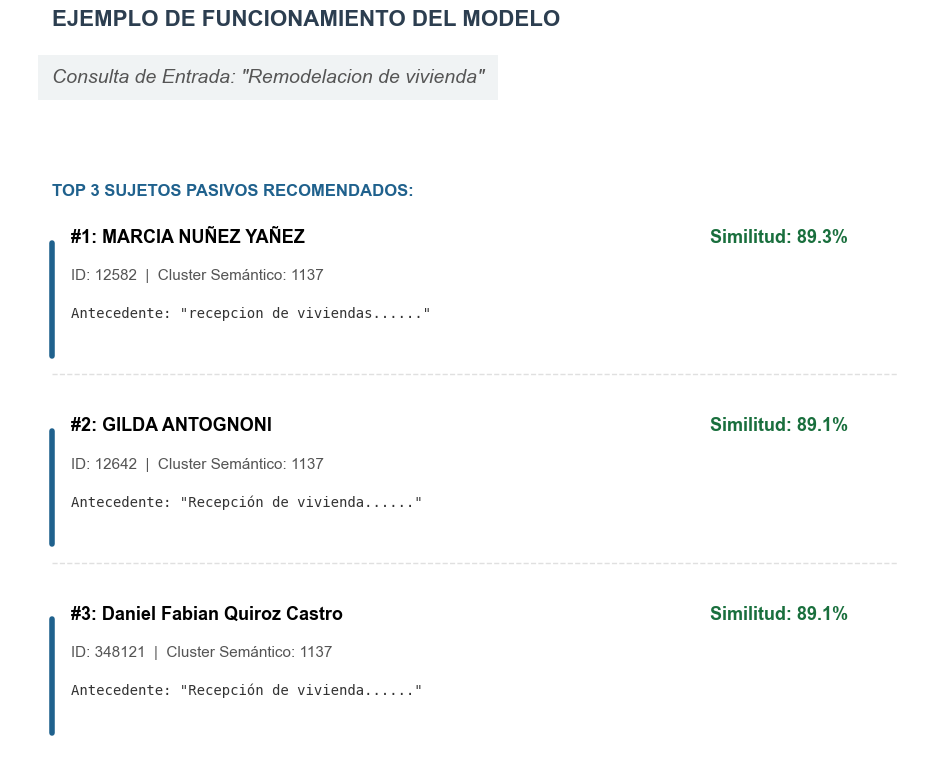

In [68]:
# 1. Definir la consulta corta
texto_ejemplo = "Remodelacion de vivienda"

# 2. Obtener recomendaciones (Usamos el mejor modelo cargado en 'recsys')
# Pedimos 3 para que no sature la imagen visualmente
df_rec_poster = recsys.recomendar(texto_ejemplo, top_k=3)

# 3. Generar la imagen para el póster
# Asegúrate de tener cargada la función 'generar_ficha_poster' que creamos antes
generar_ficha_poster(
    df_resultados=df_rec_poster, 
    df_original=df, 
    texto_query=texto_ejemplo,
    filename="ejemplo_reparacion_vivienda.png"
)

# Entrenamiento - TrainTest

In [2]:
import os
import pandas as pd 
import numpy as np

In [3]:
active_subjects = pd.read_csv(os.path.join("..", "..","data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("..", "..","data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("..", "..","data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("..", "..","data", 'passive_subjects.csv'))

In [4]:
df_grande = pd.merge(
    active_subjects,
    audiences,
    on='audiencia_id',
    how='inner'  # solo registros que existen en ambos
)

In [5]:
df = df_grande.copy()
df = df[['sujeto_pasivo_id_x','Nombre completo','materias_tratadas','especificacion']]
df = df.rename(columns={
    'sujeto_pasivo_id_x': 'pasivo_id',
    'Nombre completo': 'activo_id',
    'materias_tratadas': 'temas',
    'especificacion': 'detalle'
})

In [6]:
ruta_parquet = 'lobby_data_para_gpu.parquet'
df_parquet = pd.read_parquet(ruta_parquet)

# 2. Reemplazas la columna (usando .values para asignar por posición estricta)
# Esto asume que df tiene la misma cantidad de filas y el mismo orden que el parquet
df['detalle'] = df_parquet['detalle'].values

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("=== FASE 1: DIVISIÓN DE DATOS (TRAIN/TEST) ===")

# 1. Cargar Datos Completos (Alineados)
ruta_npy = 'embeddings_bert.npy' # O el nombre que tenga tu archivo final de Colab

print("Cargando datos maestros...")
df_full = df.copy()
emb_full = np.load(ruta_npy)

# Verificar alineación rápida
if len(df_full) != len(emb_full):
    raise ValueError(f"Descalce de dimensiones: DF {len(df_full)} vs Emb {len(emb_full)}")

# 2. Hacer el Split (80% Train, 20% Test)
# Usamos stratify=None porque no tenemos clases balanceadas a priori
# Guardamos los índices para saber quién es quién
print("Dividiendo dataset (80% Train - 20% Test)...")

indices = np.arange(len(df_full))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42)

# Crear los subconjuntos
df_train = df_full.iloc[idx_train].reset_index(drop=True)
emb_train = emb_full[idx_train]

df_test = df_full.iloc[idx_test].reset_index(drop=True)
emb_test = emb_full[idx_test]

print(f"✅ Datos de Entrenamiento (Base de Conocimiento): {len(df_train)}")
print(f"✅ Datos de Prueba (Simulación de Nuevos Casos): {len(df_test)}")

=== FASE 1: DIVISIÓN DE DATOS (TRAIN/TEST) ===
Cargando datos maestros...
Dividiendo dataset (80% Train - 20% Test)...
✅ Datos de Entrenamiento (Base de Conocimiento): 923048
✅ Datos de Prueba (Simulación de Nuevos Casos): 230762


In [8]:
import umap
import hdbscan
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

print("\n=== FASE 2: ENTRENAMIENTO DEL PIPELINE (SOLO TRAIN) ===")

# 1. PCA (Entrenado con Train)
print("1. Ajustando PCA...")
emb_train_norm = normalize(emb_train)
pca = PCA(n_components=154, random_state=42)
emb_train_pca = pca.fit_transform(emb_train_norm)

# 2. UMAP (Entrenado con Train)
print("2. Ajustando UMAP...")
# Para ser rigurosos, usamos una muestra del train para aprender la topología
TRAIN_SAMPLE_SIZE = 300000
if len(emb_train_pca) > TRAIN_SAMPLE_SIZE:
    np.random.seed(42)
    idx_sample = np.random.choice(len(emb_train_pca), size=TRAIN_SAMPLE_SIZE, replace=False)
    X_train_sample = emb_train_pca[idx_sample]
else:
    X_train_sample = emb_train_pca

mapper = umap.UMAP(
    n_neighbors=5, # O 15 si decidiste cambiarlo
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42, 
    low_memory=True,
    verbose=True
).fit(X_train_sample)

# Proyectamos TODO el conjunto de TRAIN
print("   Proyectando conjunto de Train...")
umap_embeddings_list = []
batch_size = 50000
for i in range(0, len(emb_train_pca), batch_size):
    batch = emb_train_pca[i : i + batch_size]
    batch_emb = mapper.transform(batch)
    umap_embeddings_list.append(batch_emb)

umap_train = np.vstack(umap_embeddings_list)

# 3. HDBSCAN (Clustering sobre Train)
print("3. Ejecutando HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100, # Tu configuración óptima
    min_samples=10,       # Tu configuración óptima
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels_train = clusterer.fit_predict(umap_train)

# Asignamos etiquetas SOLO al DF de Train
df_train['cluster_final'] = labels_train

# 4. (Opcional) Sub-clustering de ruido con K-Means aquí si lo usas
# ... (Inserte lógica de K-Means si aplica, usando df_train y emb_train_pca) ...

print(f"✅ Pipeline entrenado.")
print(f"   Clusters encontrados en Train: {len(np.unique(labels_train))}")


=== FASE 2: ENTRENAMIENTO DEL PIPELINE (SOLO TRAIN) ===
1. Ajustando PCA...
2. Ajustando UMAP...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Wed Dec  3 22:34:28 2025 Construct fuzzy simplicial set
Wed Dec  3 22:34:28 2025 Finding Nearest Neighbors
Wed Dec  3 22:34:28 2025 Building RP forest with 32 trees
Wed Dec  3 22:34:41 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	 6  /  18
	Stopping threshold met -- exiting after 6 iterations
Wed Dec  3 22:34:50 2025 Finished Nearest Neighbor Search
Wed Dec  3 22:34:51 2025 Construct embedding


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs
	completed  12  /  30 epochs
	completed  15  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:00]

	completed  18  /  30 epochs
	completed  21  /  30 epochs
	completed  24  /  30 epochs
	completed  27  /  30 epochs
3. Ejecutando HDBSCAN...



/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Pipeline entrenado.
   Clusters encontrados en Train: 1892


=== ANÁLISIS DE SENSIBILIDAD PARA K (SUB-CLUSTERING) ===
Total documentos de ruido a analizar: 400214
Calculando métricas (usando muestra de 200000 para Silueta)...
   Probando K=50... Silhouette: 0.0000
   Probando K=100... Silhouette: 0.0237
   Probando K=200... Silhouette: 0.0256
   Probando K=300... Silhouette: 0.0201
   Probando K=500... Silhouette: 0.0164
   Probando K=700... Silhouette: 0.0113
   Probando K=1000... Silhouette: 0.0015


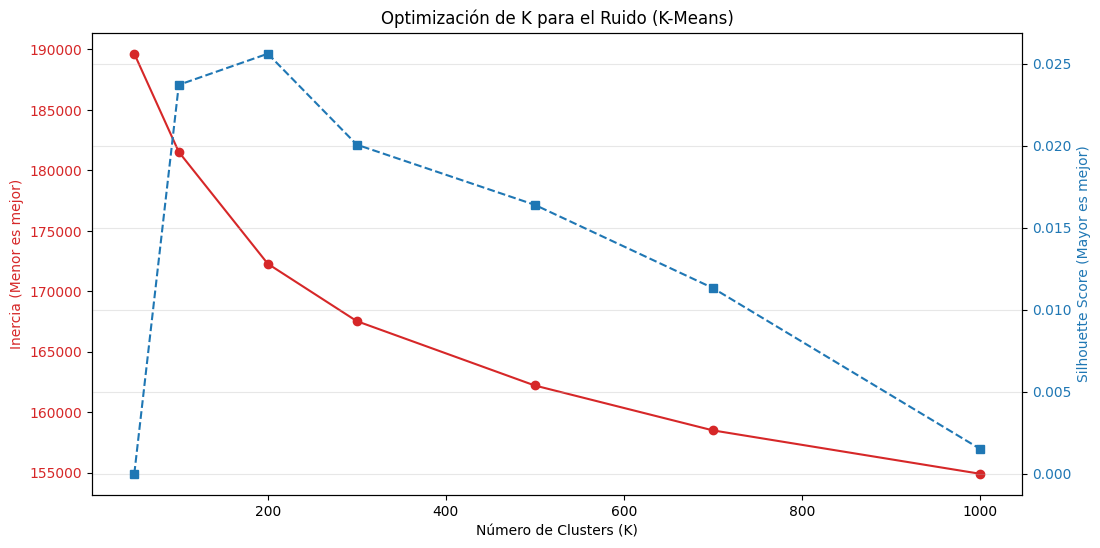

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

print("=== ANÁLISIS DE SENSIBILIDAD PARA K (SUB-CLUSTERING) ===")

# 1. Aislar el Ruido de TRAIN
# Usamos PCA (154 dims) porque es el mejor balance velocidad/información para K-Means
mask_ruido = df_train['cluster_final'] == -1
X_ruido = emb_train_pca[mask_ruido]

n_ruido = len(X_ruido)
print(f"Total documentos de ruido a analizar: {n_ruido}")

if n_ruido < 100:
    print("⚠️ Muy poco ruido para analizar. Salta este paso.")
else:
    # 2. Configurar Candidatos
    # Probamos un rango amplio para ver la tendencia
    k_candidates = [50, 100, 200, 300, 500, 700, 1000]
    inertias = []
    silhouettes = []

    # Muestra para Silhouette (máximo 20k para que corra rápido)
    sample_size = 200000 
    if n_ruido > sample_size:
        indices_sample = np.random.choice(n_ruido, sample_size, replace=False)
        X_sample = X_ruido[indices_sample]
    else:
        X_sample = X_ruido

    print(f"Calculando métricas (usando muestra de {len(X_sample)} para Silueta)...")

    # 3. Bucle de Prueba
    for k in k_candidates:
        if k >= n_ruido: break
        
        print(f"   Probando K={k}...", end=" ")
        
        # Usamos MiniBatchKMeans por velocidad
        model = MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=42, n_init='auto')
        labels = model.fit_predict(X_ruido)
        
        # Métrica 1: Inercia (Compactación)
        inertias.append(model.inertia_)
        
        # Métrica 2: Silhouette (Separación)
        # Calculamos solo sobre la muestra
        labels_sample = labels[indices_sample] if n_ruido > sample_size else labels
        try:
            score = silhouette_score(X_sample, labels_sample)
        except:
            score = 0
        silhouettes.append(score)
        
        print(f"Silhouette: {score:.4f}")

    # 4. Graficar Resultados (Doble Eje)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje Y1: Inercia (Rojo)
    color = 'tab:red'
    ax1.set_xlabel('Número de Clusters (K)')
    ax1.set_ylabel('Inercia (Menor es mejor)', color=color)
    ax1.plot(k_candidates[:len(inertias)], inertias, marker='o', color=color, label='Inercia')
    ax1.tick_params(axis='y', labelcolor=color)

    # Eje Y2: Silhouette (Azul)
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score (Mayor es mejor)', color=color)
    ax2.plot(k_candidates[:len(silhouettes)], silhouettes, marker='s', linestyle='--', color=color, label='Silhouette')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Optimización de K para el Ruido (K-Means)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Kmeans


In [10]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np
import pandas as pd

print(f"=== EJECUTANDO SUB-CLUSTERING FINAL (K=200) ===")

# 1. Separar el Ruido de TRAIN
mask_ruido = df_train['cluster_final'] == -1
X_ruido = emb_train_pca[mask_ruido] # Usamos PCA (154 dims)

print(f"Documentos a reciclar: {len(X_ruido)}")

if len(X_ruido) > 0:
    # 2. Configurar K-Means con el K ganador
    N_NUEVOS = 200
    
    print(f"Entrenando K-Means con {N_NUEVOS} clusters...")
    
    kmeans_ruido = MiniBatchKMeans(
        n_clusters=N_NUEVOS,
        batch_size=2048,
        random_state=42,
        n_init='auto'
    )
    
    # 3. Predecir
    labels_ruido = kmeans_ruido.fit_predict(X_ruido)
    
    # 4. Generar IDs únicos (Offset de 1000 para diferenciación visual)
    max_id_hdbscan = df_train['cluster_final'].max()
    offset = max_id_hdbscan + 1000 
    
    labels_ruido_finales = labels_ruido + offset

    # 5. Guardar en el DataFrame de Train
    df_train.loc[mask_ruido, 'cluster_final'] = labels_ruido_finales

    print("✅ ¡Ruido reciclado exitosamente!")
    print("-" * 40)
    print(f"   Clusters VIP (HDBSCAN):  0 a {max_id_hdbscan}")
    print(f"   Clusters Reciclados:     {offset} a {offset + N_NUEVOS - 1}")
    print("-" * 40)

else:
    print("🎉 No había ruido. Tu HDBSCAN fue perfecto (o muy permisivo).")

# Verificación final
ruido_restante = len(df_train[df_train['cluster_final'] == -1])
total_clusters = len(df_train['cluster_final'].unique())

print(f"📊 Estado Final del Dataset de Entrenamiento:")
print(f"   Ruido restante: {ruido_restante}")
print(f"   Total de Temas (Clusters): {total_clusters}")

=== EJECUTANDO SUB-CLUSTERING FINAL (K=200) ===
Documentos a reciclar: 400214
Entrenando K-Means con 200 clusters...
✅ ¡Ruido reciclado exitosamente!
----------------------------------------
   Clusters VIP (HDBSCAN):  0 a 1890
   Clusters Reciclados:     2890 a 3089
----------------------------------------
📊 Estado Final del Dataset de Entrenamiento:
   Ruido restante: 0
   Total de Temas (Clusters): 2091


# Guardar modelo

In [11]:
import joblib
import os
import numpy as np

print("=== FASE 3: GUARDADO DE ARTEFACTOS ===")

# 1. Crear estructura de carpetas
# 'sistema_lobby_final': Aquí va lo que necesita la App para correr
# 'datos_evaluacion': Aquí va lo que usaremos para calcular métricas (Hit Rate, etc.)
os.makedirs("sistema_lobby_final", exist_ok=True)
os.makedirs("datos_evaluacion", exist_ok=True)

# --- A. GUARDAR EL SISTEMA PRODUCTIVO (TRAIN) ---
print("1. Guardando Modelos y Datos de Entrenamiento...")

# Modelos Matemáticos
joblib.dump(pca, "sistema_lobby_final/pca_model.joblib")
joblib.dump(mapper, "sistema_lobby_final/umap_model.joblib")
joblib.dump(clusterer, "sistema_lobby_final/hdbscan_model.joblib")

# Base de Datos de Conocimiento (Solo Train)
# Guardamos el DF con la columna 'cluster_final' ya asignada
df_train.to_parquet("sistema_lobby_final/df_lobby_clustered.parquet")

# Guardamos los Vectores BERT originales de Train (para la similitud coseno)
np.save("sistema_lobby_final/embeddings_bert.npy", emb_train)

print(f"   -> Sistema guardado en 'sistema_lobby_final/'")

# --- B. GUARDAR DATOS DE EVALUACIÓN (TEST) ---
print("2. Guardando Set de Prueba (Hold-out)...")

# Guardamos el DF de Test (sin clusters asignados, es la realidad cruda)
df_test.to_parquet("datos_evaluacion/df_test.parquet")

# Guardamos sus vectores (para no tener que recalcularlos al evaluar)
np.save("datos_evaluacion/embeddings_test.npy", emb_test)

print(f"   -> Datos de test guardados en 'datos_evaluacion/'")

print("\n✅ ¡PROCESO COMPLETO! Ya tienes un sistema entrenado y separado correctamente.")

=== FASE 3: GUARDADO DE ARTEFACTOS ===
1. Guardando Modelos y Datos de Entrenamiento...
   -> Sistema guardado en 'sistema_lobby_final/'
2. Guardando Set de Prueba (Hold-out)...
   -> Datos de test guardados en 'datos_evaluacion/'

✅ ¡PROCESO COMPLETO! Ya tienes un sistema entrenado y separado correctamente.


In [12]:
import pandas as pd
import numpy as np

print("=== CARGANDO DATASET DE PRUEBA ===")

# Cargamos el archivo que guardamos en la Fase 3
ruta_test = "datos_evaluacion/df_test.parquet"
df_test = pd.read_parquet(ruta_test)

print(f"✅ Set de Prueba cargado: {len(df_test)} casos nuevos.")

=== CARGANDO DATASET DE PRUEBA ===
✅ Set de Prueba cargado: 230762 casos nuevos.


In [13]:
from tqdm import tqdm
from sklearn.metrics import ndcg_score
import numpy as np
from collections import Counter
import sys
import os
from contextlib import contextmanager

# Silenciador (Para que UMAP no moleste)
@contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# Función Gini
def gini_coefficient(values):
    array = np.sort(np.array(values).flatten())
    if np.amin(array) < 0: array -= np.amin(array)
    if len(array) == 0 or np.sum(array) == 0: return 0.0
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n  - 1) * array)) / (n * np.sum(array)))

def evaluar_test_set(recsys, df_test, n_muestras=1000, k=10):
    print(f"\n=== EVALUACIÓN FINAL: TEST SET (k={k}) ===")
    print(f"Usando muestra aleatoria de {n_muestras} casos del Test Set...")
    
    # Tomamos muestra del Test
    if len(df_test) > n_muestras:
        muestra = df_test.sample(n=n_muestras, random_state=42)
    else:
        muestra = df_test
    
    # Métricas
    recalls = []
    ndcgs = []
    maps = []
    
    # Para Gini (acumulamos todos los recomendados)
    todos_recomendados = []
    
    # Cache de pasivos conocidos en Train (para evitar calcular métricas imposibles)
    # Si un pasivo no existe en Train, es imposible recomendarlo (Cold Start puro)
    known_pasivos = set(recsys.df['pasivo_id'].unique())
    
    for idx, row in tqdm(muestra.iterrows(), total=len(muestra), desc="Evaluando Test"):
        texto_query = row['detalle']
        target_id = row['pasivo_id']
        
        # Si el target nunca fue visto en Train, el Recall será 0 obligatoriamente.
        # (Es una limitante del modelo, no un error de código).
        
        try:
            with suppress_all_output():
                # Pedimos recomendaciones
                res = recsys.recomendar(texto_query, top_k=k)
            
            ids_rec = res['pasivo_id'].tolist()
            todos_recomendados.extend(ids_rec)
            
            # --- 1. RECALL@K (Hit Rate) ---
            is_hit = 1 if target_id in ids_rec else 0
            recalls.append(is_hit)
            
            # --- 2. MAP@K y nDCG@K ---
            if is_hit:
                rank_pos = ids_rec.index(target_id) + 1 # 1-based
                
                # MAP (1/rank)
                maps.append(1 / rank_pos)
                
                # nDCG (1 / log2(rank+1))
                dcg = 1 / np.log2(rank_pos + 1)
                ndcgs.append(dcg) # IDCG es 1.0
            else:
                maps.append(0.0)
                ndcgs.append(0.0)
                
        except Exception as e:
            continue
            
    # --- CÁLCULO FINAL ---
    mean_recall = np.mean(recalls)
    mean_ndcg = np.mean(ndcgs)
    mean_map = np.mean(maps)
    
    # --- GINI DE RECOMENDACIONES ---
    conteo = Counter(todos_recomendados)
    freqs = list(conteo.values())
    # Rellenamos con ceros para el resto de items en Train que nunca se recomendaron
    # (Esto hace el Gini comparable con los otros modelos)
    total_items_train = len(known_pasivos)
    n_zeros = total_items_train - len(freqs)
    if n_zeros > 0:
        freqs.extend([0] * n_zeros)
        
    gini = gini_coefficient(freqs)
    
    print("\n📊 RESULTADOS FINALES (TEST SET):")
    print("-" * 40)
    print(f"✅ Recall@{k}   : {mean_recall:.4f}")
    print(f"✅ nDCG@{k}     : {mean_ndcg:.4f}")
    print(f"✅ MAP@{k}      : {mean_map:.4f}")
    print(f"⚖️ Índice Gini : {gini:.4f}")
    print("-" * 40)
    
    return mean_recall, mean_ndcg, mean_map, gini

In [18]:
import joblib
import pandas as pd
import numpy as np
import os

print("=== RECARGANDO SISTEMA PRODUCTIVO (SOLO TRAIN) ===")

# Rutas
PATH_SYSTEM = "sistema_lobby_final"

if os.path.exists(PATH_SYSTEM):
    # 1. Cargar Modelos
    print("1. Cargando modelos...")
    pca_prod = joblib.load(f"{PATH_SYSTEM}/pca_model.joblib")
    mapper_prod = joblib.load(f"{PATH_SYSTEM}/umap_model.joblib")
    clusterer_prod = joblib.load(f"{PATH_SYSTEM}/hdbscan_model.joblib")

    # 2. Cargar Base de Conocimiento (TRAIN)
    print("2. Cargando datos de entrenamiento...")
    df_train_prod = pd.read_parquet(f"{PATH_SYSTEM}/df_lobby_clustered.parquet")
    emb_train_prod = np.load(f"{PATH_SYSTEM}/embeddings_bert.npy")

    # 3. Instanciar clase limpia
    print("3. Inicializando LobbyRecommender Limpio...")
    # Asegúrate de que la clase LobbyRecommender esté definida en una celda anterior
    recsys = LobbyRecommender(
        df_data=df_train_prod, 
        embeddings_bert=emb_train_prod, 
        pca=pca_prod, 
        mapper=mapper_prod, 
        clusterer=clusterer_prod
    )
    
    print(f"✅ Sistema listo. Contiene {len(recsys.df)} documentos de conocimiento.")
    print("   (Este sistema NO conoce los datos de df_test, por lo que la evaluación será honesta).")

else:
    print(f"❌ ERROR: No encuentro la carpeta '{PATH_SYSTEM}'. ¿Ejecutaste la Fase 3 de guardado?")

=== RECARGANDO SISTEMA PRODUCTIVO (SOLO TRAIN) ===
1. Cargando modelos...
Wed Dec  3 23:17:54 2025 Building and compiling search function
2. Cargando datos de entrenamiento...
3. Inicializando LobbyRecommender Limpio...
🔄 Iniciando Recommender en: cpu
🧠 Entrenando sistema de navegación (KNN)...
✅ Sistema listo. Total temas disponibles: 2091
✅ Sistema listo. Contiene 923048 documentos de conocimiento.
   (Este sistema NO conoce los datos de df_test, por lo que la evaluación será honesta).


# Evaluacion del modelo

In [ ]:
# Evaluamos con 1000 casos del Test Set (o más si tienes tiempo)
metricas_test = evaluar_test_set(recsys, df_test, n_muestras=1000, k=10)


=== EVALUACIÓN FINAL: TEST SET (k=10) ===
Usando muestra aleatoria de 10000 casos del Test Set...


Evaluando Test: 100%|██████████| 10000/10000 [05:38<00:00, 29.54it/s]



📊 RESULTADOS FINALES (TEST SET):
----------------------------------------
✅ Recall@10   : 0.5960
✅ nDCG@10     : 0.5644
✅ MAP@10      : 0.5546
⚖️ Índice Gini : 0.8462
----------------------------------------


In [ ]:
# Evaluamos con 1000 casos del Test Set (o más si tienes tiempo)
metricas_test = evaluar_test_set(recsys, df_test, n_muestras=10000  , k=10)


=== EVALUACIÓN FINAL: TEST SET (k=10) ===
Usando muestra aleatoria de 10000 casos del Test Set...


Evaluando Test: 100%|██████████| 10000/10000 [07:56<00:00, 21.00it/s]



📊 RESULTADOS FINALES (TEST SET):
----------------------------------------
✅ Recall@10   : 0.5807
✅ nDCG@10     : 0.5481
✅ MAP@10      : 0.5379
⚖️ Índice Gini : 0.8495
----------------------------------------


In [106]:
print("=== ANÁLISIS DE FALLOS (POST-MORTEM) ===")

# 1. Identificar quiénes están en Train
pasivos_en_train = set(recsys.df['pasivo_id'].unique())

fallos_total = 0
fallos_cold_start = 0
fallos_modelo = 0

muestra = df_test.sample(n=1000, random_state=42) # Usamos la misma muestra

for idx, row in tqdm(muestra.iterrows(), total=len(muestra), desc="Analizando errores"):
    texto = row['detalle']
    target = row['pasivo_id']
    
    # Predecir (Silencioso)
    try:
        with suppress_all_output():
            res = recsys.recomendar(texto, top_k=10)
        ids_rec = res['pasivo_id'].tolist()
        
        # Si falló...
        if target not in ids_rec:
            fallos_total += 1
            
            # ¿Fue culpa de Cold Start?
            if target not in pasivos_en_train:
                fallos_cold_start += 1
            else:
                fallos_modelo += 1 # El sujeto existía, pero el modelo no lo vio
    except:
        continue

print(f"\n📊 DESGLOSE DE ERRORES (Total Fallos: {fallos_total})")
print(f"   ❄️ Cold Start (Imposible de predecir): {fallos_cold_start} ({fallos_cold_start/fallos_total:.1%})")
print(f"   🧠 Error del Modelo (Confusión):       {fallos_modelo} ({fallos_modelo/fallos_total:.1%})")

# Recall Ajustado (Si quitáramos los imposibles)
recall_ajustado = (1000 - fallos_modelo) / 1000
print(f"\n🚀 RECALL POTENCIAL (Si actualizáramos la base): {recall_ajustado:.2%}")

=== ANÁLISIS DE FALLOS (POST-MORTEM) ===


Analizando errores: 100%|██████████| 1000/1000 [00:27<00:00, 36.49it/s]


📊 DESGLOSE DE ERRORES (Total Fallos: 384)
   ❄️ Cold Start (Imposible de predecir): 5 (1.3%)
   🧠 Error del Modelo (Confusión):       379 (98.7%)

🚀 RECALL POTENCIAL (Si actualizáramos la base): 62.10%


--- REPORTE DE PCA ---
Dimensiones reducidas: de 768 a 50
Varianza (Información) Conservada: 54.97%
Pérdida de Información: 45.03%


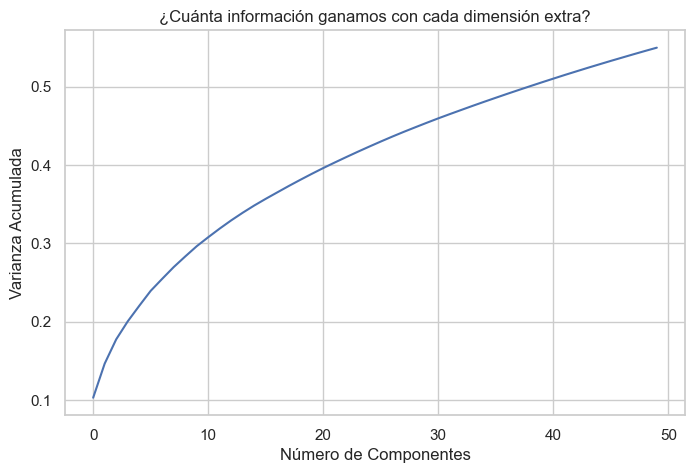

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular la varianza total acumulada
varianza_total = np.sum(pca.explained_variance_ratio_)

print(f"--- REPORTE DE PCA ---")
print(f"Dimensiones reducidas: de 768 a {pca.n_components_}")
print(f"Varianza (Información) Conservada: {varianza_total * 100:.2f}%")
print(f"Pérdida de Información: {(1 - varianza_total) * 100:.2f}%")

# 2. (Opcional) Gráfico de Varianza Acumulada
# Esto sirve para ver si 75 componentes fue una buena elección
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('¿Cuánta información ganamos con cada dimensión extra?')
plt.grid(True)
plt.show()

=== DIAGNÓSTICO DE VARIANZA PCA ===
✅ Para conservar el 90% de varianza necesitas: 244 dimensiones.
✅ Para conservar el 80% de varianza necesitas: 154 dimensiones.


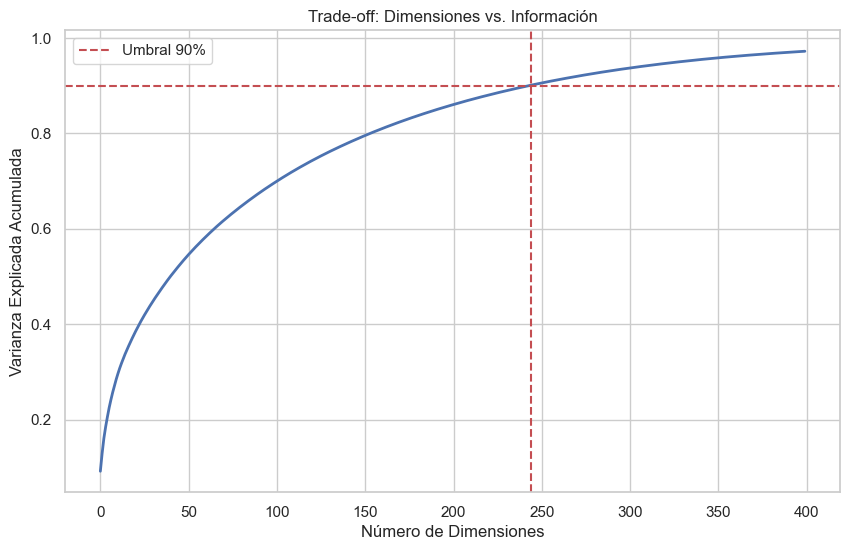

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("=== DIAGNÓSTICO DE VARIANZA PCA ===")

# 1. Tomar una muestra para no saturar la RAM (50k es suficiente estadística)
# Asumiendo que 'emb_input' son tus embeddings normalizados
sample_size = 50000 
indices = np.random.choice(len(emb_full), size=min(len(emb_full), sample_size), replace=False)
X_sample = emb_full[indices]

# 2. Entrenar PCA con muchas dimensiones (ej. 400) para ver hasta dónde llega
# SBERT tiene máximo 768, así que 400 es un buen límite de prueba
pca_test = PCA(n_components=400, random_state=42)
pca_test.fit(X_sample)

# 3. Calcular la varianza acumulada
cumsum = np.cumsum(pca_test.explained_variance_ratio_)

# 4. Encontrar el punto exacto del 90% (0.90)
# argmax devuelve el primer índice donde la condición es True
n_dims_90 = np.argmax(cumsum >= 0.90) + 1 
n_dims_80 = np.argmax(cumsum >= 0.80) + 1 

print(f"✅ Para conservar el 90% de varianza necesitas: {n_dims_90} dimensiones.")
print(f"✅ Para conservar el 80% de varianza necesitas: {n_dims_80} dimensiones.")

# 5. Gráfico (El "Codo" de PCA)
plt.figure(figsize=(10, 6))
plt.plot(cumsum, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='Umbral 90%')
plt.axvline(x=n_dims_90, color='r', linestyle='--')
plt.xlabel('Número de Dimensiones')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Trade-off: Dimensiones vs. Información')
plt.legend()
plt.grid(True)
plt.show()